In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'D:\New folder\CVS_DS\train'
validation_dir = r'D:\New folder\CVS_DS\validation'
test_dir = r'D:\New folder\CVS_DS\test'

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

c:\Users\User\anaconda3\envs\first_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss ='categorical_crossentropy', optimizer=optimizers.RMSprop(1e-4), metrics=['acc'])

In [7]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [11]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 5,
                         callbacks = callbacks)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.4437 - loss: 1.1862
Epoch 1: val_loss improved from inf to 0.73530, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-0001-loss0.74.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 241s 5s/step - acc: 0.4461 - loss: 1.1823 - val_acc: 0.6429 - val_loss: 0.7353
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.7305 - loss: 0.6264
Epoch 2: val_loss improved from 0.73530 to 0.45088, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-0002-loss0.45.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - acc: 0.7308 - loss: 0.6253 - val_acc: 0.7500 - val_loss: 0.4509
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.7958 - loss: 0.4548
Epoch 3: val_loss improved from 0.45088 to 0.38917, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-0003-loss0.39.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - acc: 0.7956 - loss: 0.4548 - val_acc: 0.8170 - val_loss: 0.3892
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.7959 - loss: 0.4499
Epoch 4: val_loss did not improve from 0.38917
50/50 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - acc: 0.7964 - loss: 0.4492 - val_acc: 0.7679 - val_loss: 0.4767
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.8333 - loss: 0.3781
Epoch 5: val_loss improved from 0.38917 to 0.34693, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-0005-loss0.35.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - acc: 0.8335 - loss: 0.3777 - val_acc: 0.8259 - val_loss: 0.3469


In [12]:
model_history.history

{'acc': [0.565625011920929,
  0.75,
  0.7875000238418579,
  0.8174999952316284,
  0.8412500023841858],
 'loss': [0.9872425198554993,
  0.5720422267913818,
  0.45287230610847473,
  0.413319855928421,
  0.35740676522254944],
 'val_acc': [0.6428571343421936,
  0.75,
  0.8169642686843872,
  0.7678571343421936,
  0.8258928656578064],
 'val_loss': [0.7352997064590454,
  0.4508773684501648,
  0.389169305562973,
  0.47670361399650574,
  0.34692883491516113]}

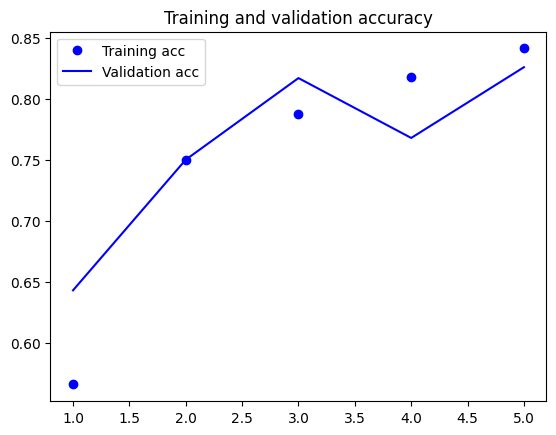

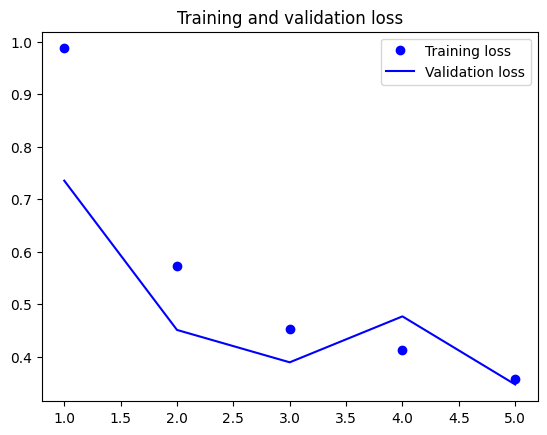

<Figure size 640x480 with 0 Axes>

In [13]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'C:\Users\User\anaconda3\envs\first_env\Lab_13\model_Accuracy.png')

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step  


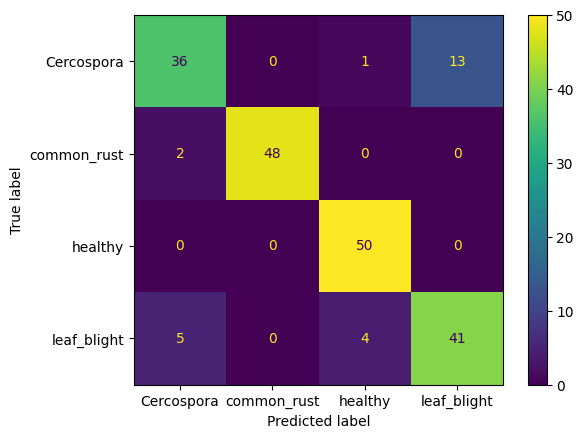

In [18]:
model = load_model(r'C:\Users\User\anaconda3\envs\first_env\Lab_13\\E1-cp-0005-loss0.35.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab_13\confusion_matrics.jpg')

In [19]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.84      0.72      0.77        50
 common_rust       1.00      0.96      0.98        50
     healthy       0.91      1.00      0.95        50
 leaf_blight       0.76      0.82      0.79        50

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.87       200

